---
title: "DAG rules"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: true
    code-summary: "Show the code"
    css: /mermaid_custom_DAG3.css
---

## 3 kinds of junctions

Directed Acyclic Graphs (DAGs) encode the causal information between random variables. Writing $A\rightarrow B$ means A has a direct causal influence on B. The absence of an arrow encodes an assumption of no direct causal effect.

### the chain (mediation)

```{mermaid}
graph LR
    A[A] --> B["B<br>mechanism"] --> C[C]
```

An example by Pearl:

```{mermaid}
graph LR
    A[fire] --> B[smoke] --> C[alarm]
```

* The fire does not directly set off the alarm, so there is no arrow between them.
* The fire does not set off an alarm through another mechanism, such as heat, so there are no other arrows that leave out of fire.

The mediator B "screens off" information about A from C, and vice versa.

* If we know the value of "smoke", learning about "fire" does not give us any reason to raise or lower our belief in "alarm".

Say that we have a table with 3 columns: fire, smoke, alarm. Each row is a data point, where 0 denotes "no" and 1 denotes "yes". So $(0,0,0)$ means that there was no fire, no smoke, and no alarm.


| fire | smoke | alarm |
| ---- | ----- | ----- |
| 0 | 0 | 0 |
| 1 | 1 | 1 |
| 1 | 1 | 1 |
| 0 | 0 | 0 |
| etc | etc | etc |

The table above describes a world where everytime when there's a fire, there's smoke, and smoke always sets off the alarm.

We can only look at the row where smoke equals 1. This is called **conditioning on a variable**. We will denote conditioning by shading the variable gray:

```{mermaid}
graph LR
    A[fire] --> B[smoke]:::conditioned --> C[alarm]
```

In this perfect world, if we only look at the rows where smoke=1, we will expect to have alarm=1 every time, regardless whether fire=0 or fire=1.

We might have a faulty alarm system, one that fails to respond correctly to smoke 5 percent of the time. In that case, if we look only at the rows where smoke=1 (i.e., we condition on smoke), we will find that the probability that alarm=1 is 95%, regardless whether fire=0 or fire=1.

Conditioning on the mechanism/mediator B screened off the flow of information between A and C. Whenever we have a chain, conditioning on a variable closes off the flow of information. By ‘flow of information’, we mean whether A and C are statistically dependent.

### the fork (confounding)

```{mermaid}
graph TD
    B["B<br>confounding"] --> A[A]
    B --> C[C]
```

The confounder B makes A and C statistically correlated even though there is no direct causal link between them.

An example from Pearl:

```{mermaid}
graph TD
    B["age of child<br>(confounding)"] --> A[shoe size]
    B --> C[reading ability]
```

Children with larger shoe sizes tend to read at a higher level. But this relationship is not one of cause and effect. Giving a child larger shoes won't make them read better. Instead, both variables are explained by a third, age. Older children have larger shoes, and they also are more advanced readers.

We can eliminate this correlation by conditioning on the child's age. Conditioning on the confounder blocks the path between A and C.

```{mermaid}
graph TD
    B["age of child<br>(confounding)"]:::conditioned --> A[shoe size]
    B --> C[reading ability]
```

Imagine we have a table with three columns: age, shoe size, and reading ability. Conditioning for age means that we only select rows that have the same value of age. In that case, there won't be any correlation between shoe size and reading ability. We then say that A and C are conditionally independent, given B. We can express that mathematically as $A \perp C \mid B$. This last expression can be written more explicitly as:

$$
P(A,C \mid B) = P(A \mid B)\cdot P(C \mid B).
$$

### the collider (selection bias)

```{mermaid}
graph TD
    A[A] --> B["B<br>(collider)"]
    C[C] --> B
```

An example from Pearl. Big Hollywood movie actors are chosen either because of their beauty or because of their talent.

```{mermaid}
graph TD
    A[beauty] --> B["actor being chosen<br>(collider)"]
    C[talent] --> B
```

In the general population, beauty and talent are completely uncorrelated. The fact that we know an actor was chosen to star in a Hollywood movie makes these traits correlated for that actor. Think about it: Hollywood can choose an actor who is good looking, talented, or both, but **never** neither. This selection bias introduces a negative correlation between beauty and talent, once casting is controlled for. If I learn that a given actor is super talented, this information decreases my belief that they are good-looking.

```{mermaid}
graph TD
    A[beauty] --> B["actor being chosen<br>(collider)"]:::conditioned
    C[talent] --> B
```


In the previous two junctions, the information flow was blocked once we conditioned on the relevant variable. Here it's the opposite! When the collider variable B is not conditioned for, A and C are uncorrelated. In our example, that is to say that beauty and talent are uncorrelated in the general population. Once B is controlled for, then A and C will be correlated.

To get an intuition of why beauty and talent become negatively correlated once we condition on the person being chosen to be on a movie, see the graphs below.

In [22]:
#| code-summary: "import libraries"
import numpy as np
import matplotlib.pyplot as plt

In [23]:
#| code-summary: "generate data"
rng = np.random.RandomState(1)
N=70
x = rng.uniform(size=N)
y = rng.uniform(size=N)
cond_x = x > 0.5
cond_y = y > 0.5
x2 = x[cond_x | cond_y]
y2 = y[cond_x | cond_y]
x3 = x[~cond_x & ~cond_y]
y3 = y[~cond_x & ~cond_y]

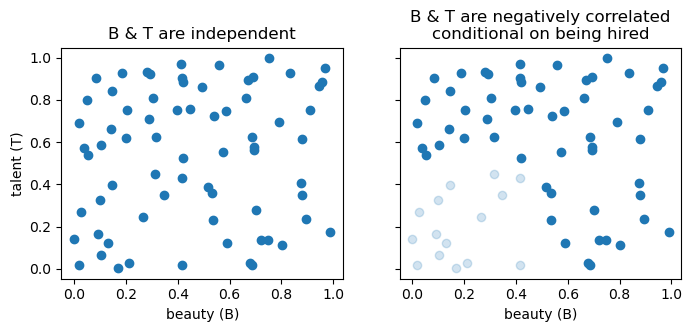

In [24]:
#| code-summary: "plot"
fig, ax = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)
ax[0].scatter(x, y)
ax[1].scatter(x2, y2, color="C0")
ax[1].scatter(x3, y3, color="C0", alpha=0.2)
ax[0].set(xlabel="beauty (B)",
          ylabel="talent (T)",
          title="B & T are independent")
ax[1].set(xlabel="beauty (B)",
          title="B & T are negatively correlated\nconditional on being hired");

### the descendant of a collider

This demonstrates the trickier rule: conditioning on $D$ (a descendant of $B$) also opens the path between $A$ and $C$.

```{mermaid}
graph TD
    A[A] --> B["B<br>(collider)"] --> D[D]
    C[C] --> B
```

Example from Pearl.

The grass outside may become wet either because of the rain or because the sprinklers were turned on. In general, there is no correlation whatsoever between the timing of rainfall events and the opening of sprinklers.

If I look outside and see the grass wet, that information introduces a correlation between the probability that it rained and the probability that the sprinklers were on. So far so good, this is the classic collider story.

If I haven’t looked at the grass, but instead I see my child entering the house with muddy shoes, that information will also introduce a correlation between rainfall and sprinklers. The muddy shoes are evidence that the grass is (or was) wet, even if I did not observe it directly. In that sense, observing a consequence of the wet grass plays a similar role to observing the wet grass itself.

More generally, conditioning on a collider or on any of its descendants opens the path.

## summary

* chain $A \rightarrow B \rightarrow C$:  
  The path between A and C is "open" by default, but conditioning on B blocks it.

* fork $A \leftarrow B \rightarrow C$:  
  The path between A and C is "open" by default, but conditioning on B blocks it.

* collider $A \rightarrow B \leftarrow C$:  
  The path between A and C is **"blocked"** by default, but conditioning on B opens it.  
  Conditioning on any descendant of the collider also opens the path.

These rules determine which variables we should control for when estimating causal effects